In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from scipy.io import loadmat
from mne.time_frequency import tfr_morlet
from tqdm import tqdm
import os
import glob

In [2]:
data = np.load("./data/sub-01/preprocessed_eeg_training.npz")
print(data.files)

['preprocessed_eeg_data', 'ch_names', 'times']


In [3]:
label = np.load("./data/sub-01/train_concepts.npy")
label[:5]

array(['aardvark', 'aardvark', 'aardvark', 'aardvark', 'aardvark'],
      dtype='<U18')

In [12]:
to_use_ch = ['P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'Oz', 'O2']
times = data["times"]
dt = np.mean(np.diff(times))
fs = 1.0 / dt
freqs = np.arange(1, 41, 1)
n_cycles = freqs / 2.0

### Obtain data from preprocessing script

`spectrogram_avg.py`

In [4]:
out_dir = "./data/sub-01_spectrogram_avg_batches"
batch_files = sorted(glob.glob(os.path.join(out_dir, "batch_*.npy")))
all_tfr = np.concatenate([np.load(f) for f in batch_files], axis=0)

In [16]:
arr = all_tfr[0]

info = mne.create_info(
    ch_names=data["ch_names"].tolist(),
    sfreq=fs,
    ch_types="eeg",
)

tfr_obj = mne.time_frequency.AverageTFRArray(
    info=info,
    data=arr,
    times=times,
    freqs=freqs,
    nave=1,
    method="morlet",
)

  0%|          | 0/8 [00:00<?, ?it/s]

No baseline correction applied


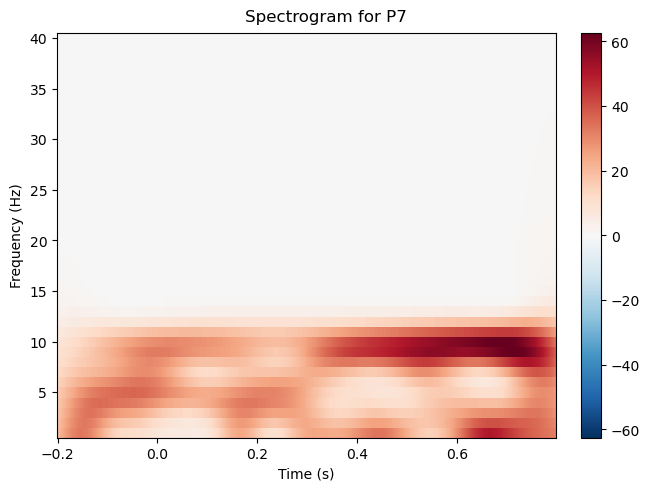

 12%|█▎        | 1/8 [00:00<00:02,  2.89it/s]

No baseline correction applied


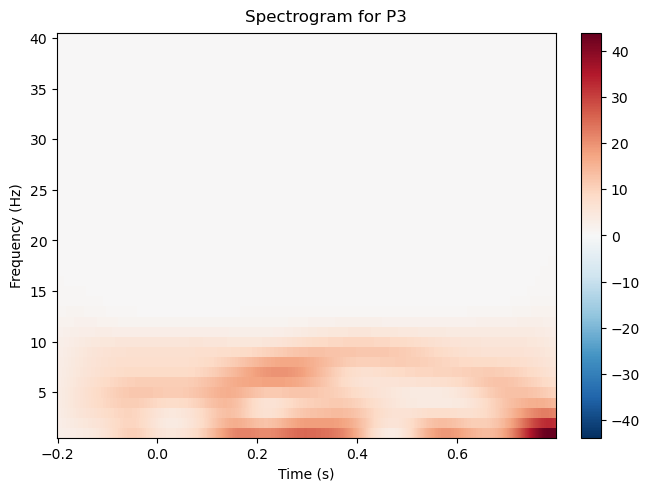

 25%|██▌       | 2/8 [00:00<00:01,  3.81it/s]

No baseline correction applied


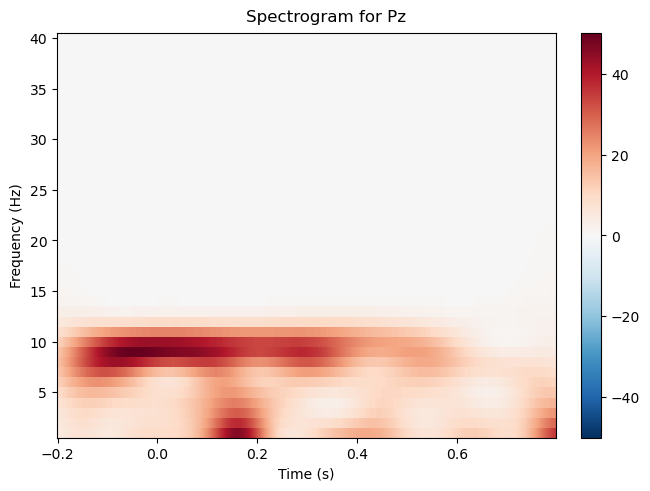

 38%|███▊      | 3/8 [00:00<00:01,  4.35it/s]

No baseline correction applied


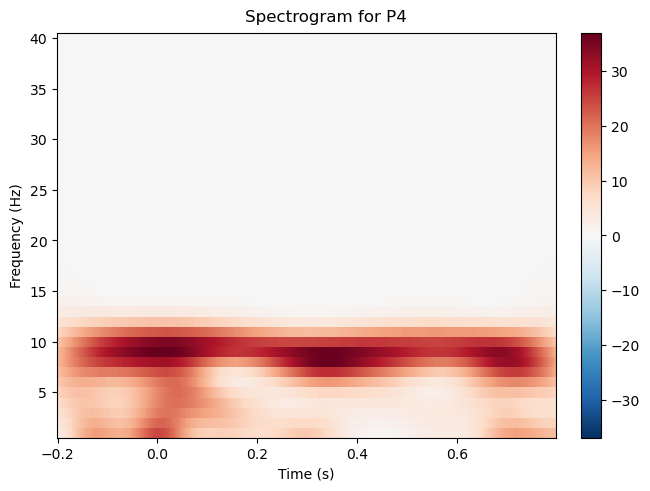

 50%|█████     | 4/8 [00:00<00:00,  4.60it/s]

No baseline correction applied


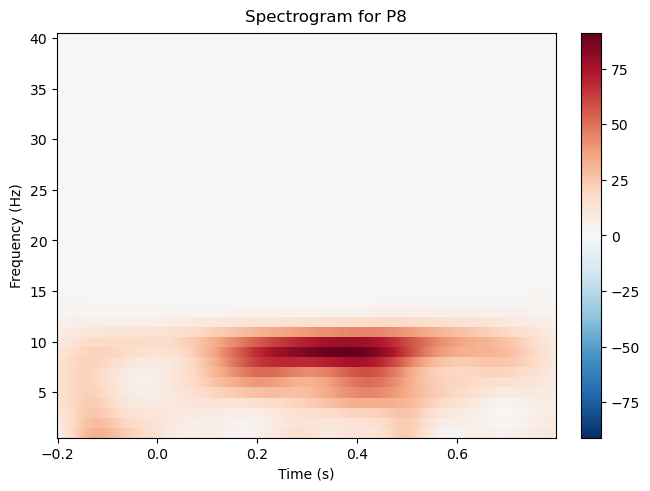

 62%|██████▎   | 5/8 [00:01<00:00,  4.77it/s]

No baseline correction applied


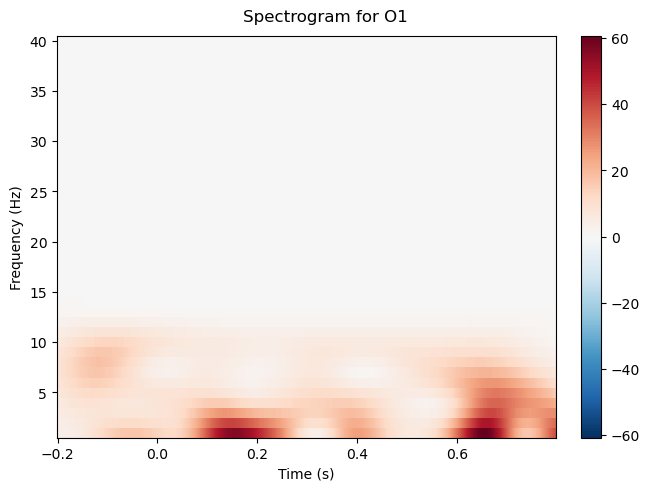

 75%|███████▌  | 6/8 [00:01<00:00,  4.87it/s]

No baseline correction applied


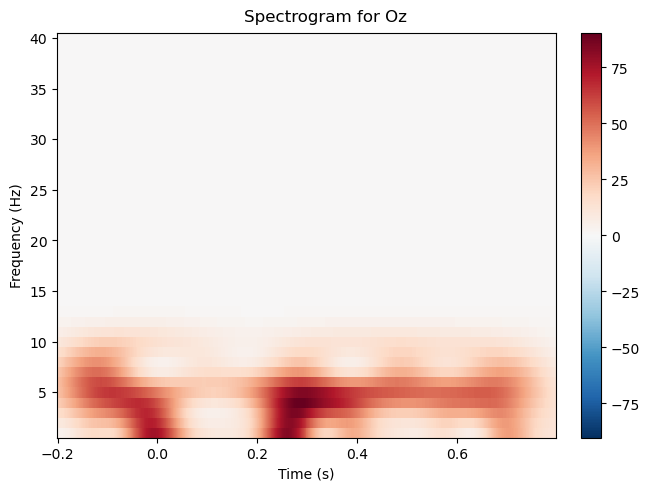

 88%|████████▊ | 7/8 [00:01<00:00,  4.93it/s]

No baseline correction applied


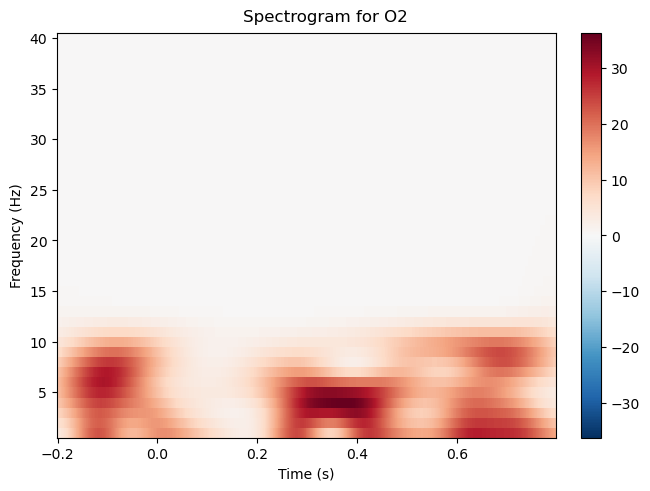

100%|██████████| 8/8 [00:01<00:00,  4.63it/s]


In [17]:
for name in tqdm(to_use_ch):
    cur_idx = data['ch_names'].tolist().index(name)
    tfr_obj.plot([cur_idx], title=f"Spectrogram for {name}")